In [1]:
import cv2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

import random
from glob import glob
import os
from tqdm.notebook import tqdm

import IPython.display as ipd

In [2]:
glob_path = [i for i in glob('Dataset\*\*\*.mp4')]
output_label = [i for i in glob('Dataset\*\*')]

glob_path,output_label

(['Dataset\\Adjectives\\Blind\\1-1.mp4',
  'Dataset\\Adjectives\\Blind\\1-2.mp4',
  'Dataset\\Adjectives\\Blind\\1-3.mp4',
  'Dataset\\Adjectives\\Blind\\1-4.mp4',
  'Dataset\\Adjectives\\Blind\\1-5.mp4',
  'Dataset\\Adjectives\\Blind\\1-6.mp4',
  'Dataset\\Adjectives\\Blind\\1-7.mp4',
  'Dataset\\Adjectives\\Blind\\1-8.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-1.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-2.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-3.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-4.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-5.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-6.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-7.mp4',
  'Dataset\\Adjectives\\Deaf\\Deaf-8.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-1.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-2.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-3.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-4.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-5.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-6.mp4',
  'Dataset\\Adjectives\\Flat\\Flat-7.mp4',
  'Dataset\\Adjectives\\Fla

In [3]:
random_video = random.choice(glob_path)
print(random_video.split("\\")[-2:])

cap = cv2.VideoCapture(random_video)
print(f"Video Resolution: {cap.get(cv2.CAP_PROP_FRAME_WIDTH)} x {cap.get(cv2.CAP_PROP_FRAME_HEIGHT)}")
print(f"FPS: {cap.get(cv2.CAP_PROP_FPS)}")

ipd.Video(random_video,width=700)

['Quiet', 'quiet-4.mp4']
Video Resolution: 1280.0 x 720.0
FPS: 25.0


In [4]:
cap = cv2.VideoCapture(random_video)
ret, img = cap.read()
print(f'Returned {ret} and img of shape {img.shape}')

Returned True and img of shape (720, 1280, 3)


In [5]:
def display_cv2_img(img, figsize=(10, 10)):
    img_ = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    fig, ax = plt.subplots(figsize=figsize)
    ax.imshow(img_)
    ax.axis("off")

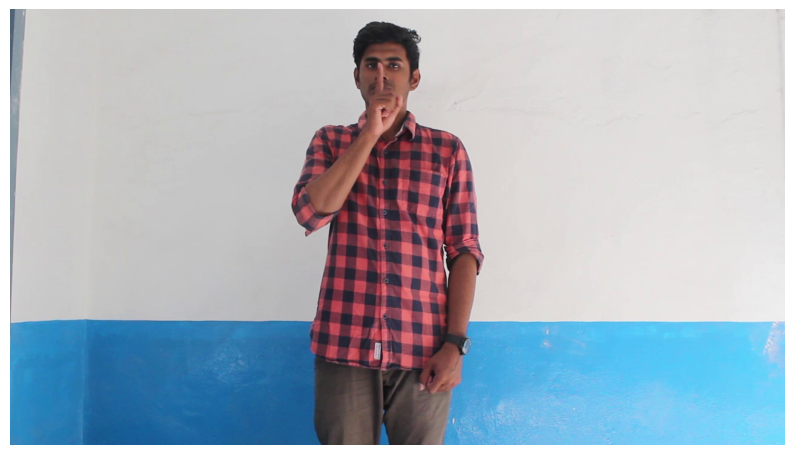

In [6]:
display_cv2_img(img)
cap.release()

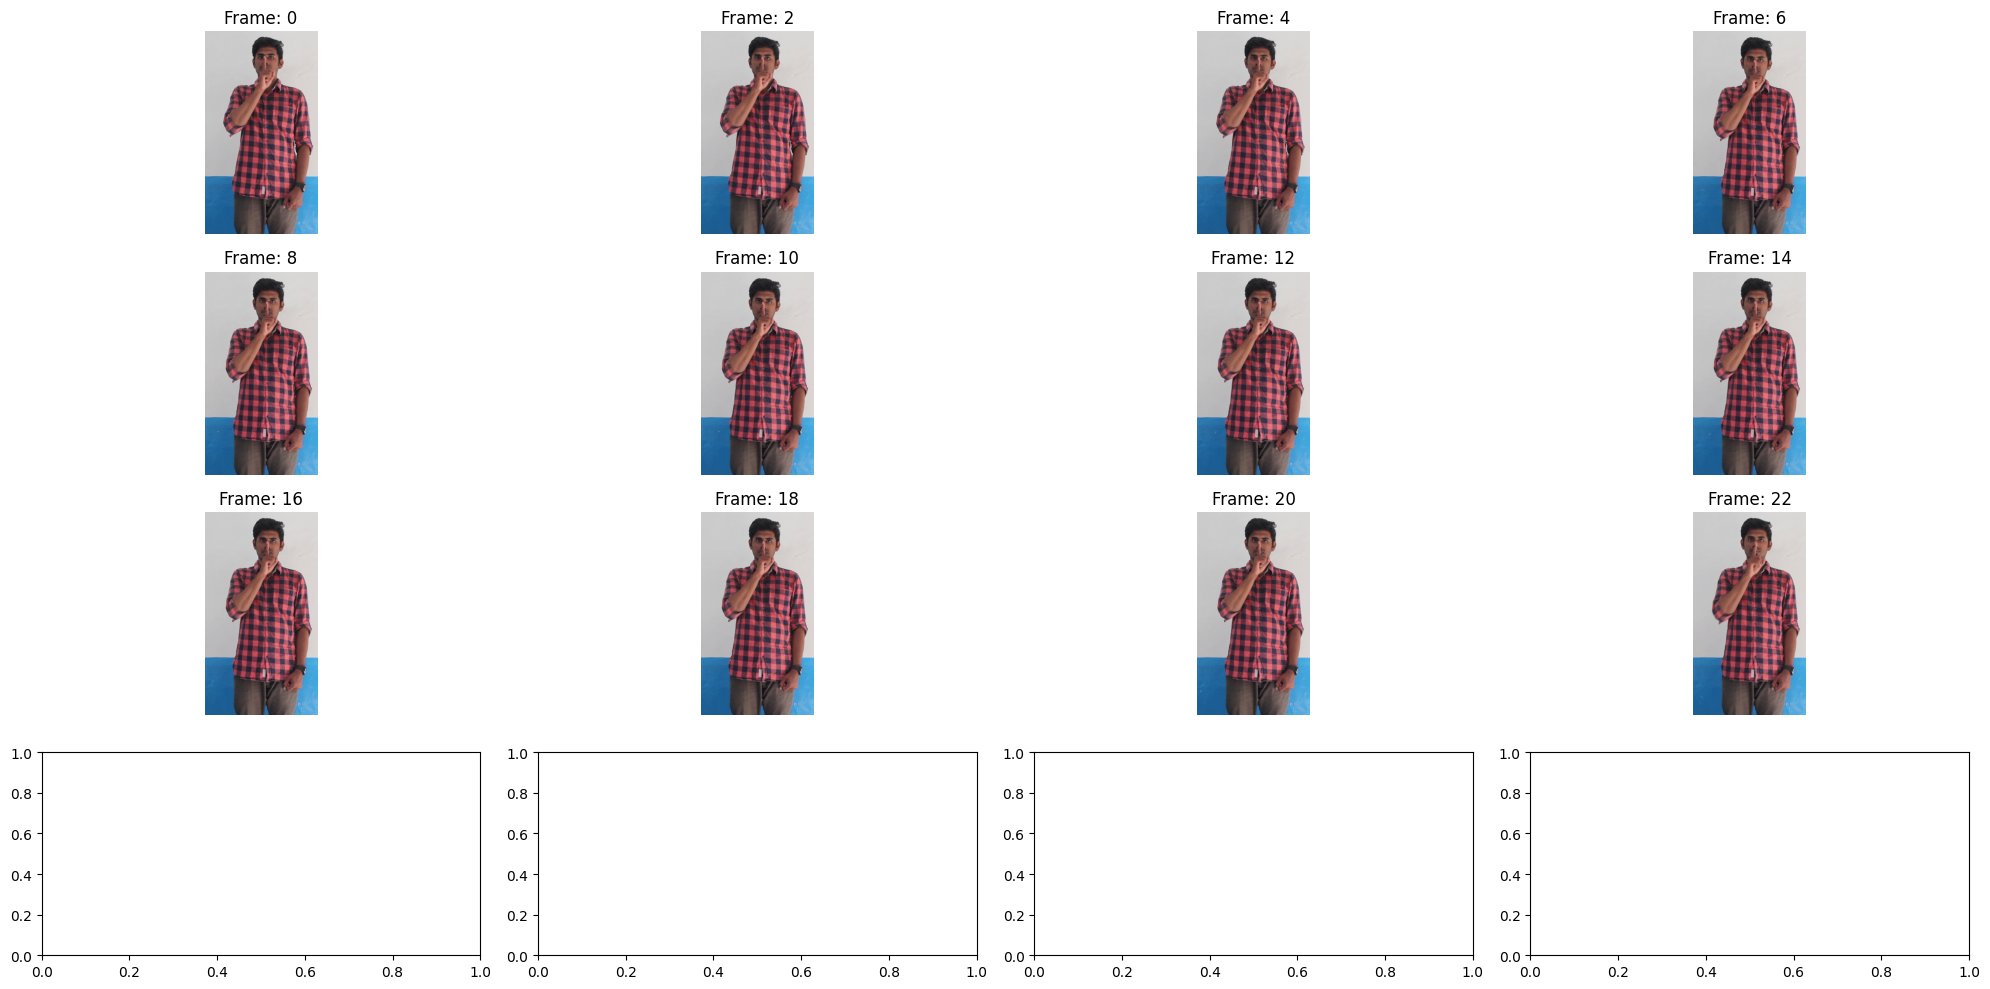

In [7]:
fig, axs = plt.subplots(4, 4, figsize=(20, 10))
axs = axs.flatten()

cap = cv2.VideoCapture(random_video)
n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))


img_idx = 0
for frame in range(n_frames):
    ret, img = cap.read()
    img = img[:,400:800]
    
    if ret == False:
        break
    if frame % 2 == 0:
        axs[img_idx].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        axs[img_idx].set_title(f'Frame: {frame}')
        axs[img_idx].axis('off')
        img_idx += 1

plt.tight_layout()
plt.show()
cap.release()

## Vedio Augmentaion

1. Org  
2. Centre Crop
3. Flip
4. Upsample
5. Downsample

### Optional (Optional Experimentrs)
6. sharpen 
7. blurred
8. Frame Skipping

### Centre Crop

In [8]:
def centered_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30
    width = 400
    height = 720
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,400:800] # Cropping
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Flip


In [9]:
def flip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1280
    height = 720
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[:,::-1] # Flipping
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Downsampling

In [10]:
def downsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    
    VIDEO_CODEC = "MP4V"
    fps = 30
    width = 640
    height = 360
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))


    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrDown(img) # Downsampling
        # print(img.shape)
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Upsampling


In [11]:
def upsample_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 3840
    height = 2160
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))



    for frame in range(n_frames):
        ret, img = cap.read()
        img = cv2.pyrUp(img) # Upsampling
        
        if ret == False:
            break
        
        out.write(img)

    out.release()
    cap.release()


### Clipping


In [12]:
def clip_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)

    VIDEO_CODEC = "MP4V"
    fps = 25
    width = 1920
    height = 1080
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    counter = 0
    for frame in range(n_frames):
        ret, img = cap.read()
        if ret == False:
            break
        
        if counter >= 10 and counter < n_frames-20:    
            out.write(img)
        
        counter += 1

    out.release()
    cap.release()


### Horizontal Crop

In [13]:
def horizontal_video(org_video, save_path, cap, n_frames):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30
    height = 590
    width = 1280
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read()
        img = img[0:height] 
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

### Speeding Up

In [14]:
def fast_video(org_video, save_path, cap, n_frames, speed):
    cap = cv2.VideoCapture(org_video)
    VIDEO_CODEC = "MP4V"
    fps = 30 * speed
    height = 720
    width = 1280
    out = cv2.VideoWriter(save_path,
                    cv2.VideoWriter_fourcc(*VIDEO_CODEC),
                    fps,
                    (width, height))

    for frame in range(n_frames):
        ret, img = cap.read() 
        
        if ret == False:
            break
        out.write(img)

    out.release()
    cap.release()

In [ ]:
# input_video = "Dataset\Adjectives\Blind\\1-2.mp4"
# cap = cv2.VideoCapture(input_video)
# n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))      

# # save_path = "test.mp4"
# fast_video(input_video, "test.mp4", cap, n_frames,1.1)
# fast_video(input_video, "test1.mp4", cap, n_frames,1.25)
# fast_video(input_video, "test2.mp4", cap, n_frames,1.35)

In [66]:
for label in tqdm(glob('Dataset\*\*')): 
    label_name = " ".join(((label.split("\\")[-1]).split(" "))[1:]) # First seprated the label from dir then sep the label from its number and then join the label
    
    folder = "Cropped"

    os.makedirs(os.path.join(label,folder), exist_ok=True)
    videos = os.listdir(label)
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):
        if "Cro" in video:
            continue
        input_video = os.path.join(label, video)
        cap = cv2.VideoCapture(input_video)
        n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,folder,f"{video[:-4]}.mp4")
        horizontal_video(input_video, save_path, cap, n_frames)

  0%|          | 0/10 [00:00<?, ?it/s]

Blind:   0%|          | 0/9 [00:00<?, ?it/s]

Deaf:   0%|          | 0/9 [00:00<?, ?it/s]

Flat:   0%|          | 0/9 [00:00<?, ?it/s]

Happy:   0%|          | 0/16 [00:00<?, ?it/s]

...

Quiet:   0%|          | 0/22 [00:00<?, ?it/s]

Rich:   0%|          | 0/9 [00:00<?, ?it/s]

sad:   0%|          | 0/9 [00:00<?, ?it/s]

Slow:   0%|          | 0/19 [00:00<?, ?it/s]

Thick:   0%|          | 0/9 [00:00<?, ?it/s]

## Genrating all the augmented content


In [15]:
for label in tqdm(glob('Dataset\*\*')): 
    os.makedirs(os.path.join(label,"Augmentation"), exist_ok=True)
    videos = os.listdir(label)[1:]
    
    for video in tqdm(videos,desc=label.split("\\")[-1]):        
        input_video = os.path.join(label, video)
        n_frames = int(cv2.VideoCapture(input_video).get(cv2.CAP_PROP_FRAME_COUNT))      

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_centered.mp4")
        centered_video(input_video, save_path, cap, n_frames)

        # save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_flipped.mp4") 
        # flip_video(input_video, save_path, cap, n_frames)

        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_downsampled.mp4") 
        downsample_video(input_video, save_path, cap, n_frames)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_1X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.1)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_25X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.25)
        
        save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_1_35X.mp4")
        fast_video(input_video, save_path, cap, n_frames,1.35)

        # save_path = os.path.join(label,"Augmentation",f"{video[:-4]}_upsampled.mp4") 
        # upsample_video(input_video, save_path, cap, n_frames)
    

  0%|          | 0/10 [00:00<?, ?it/s]

Blind:   0%|          | 0/8 [00:00<?, ?it/s]

Deaf:   0%|          | 0/8 [00:00<?, ?it/s]

Flat:   0%|          | 0/8 [00:00<?, ?it/s]

Happy:   0%|          | 0/15 [00:00<?, ?it/s]

...

Quiet:   0%|          | 0/21 [00:00<?, ?it/s]

Rich:   0%|          | 0/8 [00:00<?, ?it/s]

sad:   0%|          | 0/8 [00:00<?, ?it/s]

Slow:   0%|          | 0/18 [00:00<?, ?it/s]

Thick:   0%|          | 0/8 [00:00<?, ?it/s]